In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/logistics_shipments_dataset.csv')
df.head()

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
0,SH10000,Warehouse_MIA,San Francisco,UPS,2023-10-02,2023-10-04,25.7,67.46,Delivered,291,2
1,SH10001,Warehouse_MIA,Atlanta,DHL,2023-12-06,2023-12-09,38.9,268.85,Delivered,1225,3
2,SH10002,Warehouse_LA,Houston,DHL,2023-09-18,2023-09-20,37.2,74.35,Delivered,220,2
3,SH10003,Warehouse_BOS,Seattle,OnTrac,2023-01-26,2023-02-04,42.6,187.04,Delivered,1156,9
4,SH10004,Warehouse_SF,Dallas,OnTrac,2023-06-03,2023-06-06,7.9,120.01,Delivered,1017,3


In [3]:
df.shape

(2000, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Shipment_ID       2000 non-null   object 
 1   Origin_Warehouse  2000 non-null   object 
 2   Destination       2000 non-null   object 
 3   Carrier           2000 non-null   object 
 4   Shipment_Date     2000 non-null   object 
 5   Delivery_Date     1968 non-null   object 
 6   Weight_kg         2000 non-null   float64
 7   Cost              1959 non-null   float64
 8   Status            2000 non-null   object 
 9   Distance_miles    2000 non-null   int64  
 10  Transit_Days      2000 non-null   int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 172.0+ KB


In [5]:
df.describe()

,Weight_kg,Cost,Distance_miles,Transit_Days
count,2000.000000,1959.000000,2000.000000,2000.000000
mean,30.184800,205.161598,1275.868000,4.182500
std,124.967053,222.586082,691.382829,1.837902
min,0.000000,17.890000,101.000000,1.000000
25%,12.300000,117.710000,690.250000,3.000000
50%,20.700000,196.420000,1262.500000,4.000000
75%,33.925000,272.115000,1867.250000,5.000000
max,5404.200000,6562.210000,2499.000000,12.000000


In [6]:
df.sample(10)

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
751,SH10751,Warehouse_BOS,Phoenix,LaserShip,2023-08-22,2023-09-02,43.8,138.23,Delayed,691,3
1277,SH11277,Warehouse_LA,Minneapolis,USPS,2023-05-16,2023-05-23,24.0,307.61,Delivered,2479,7
673,SH10673,Warehouse_NYC,Seattle,LaserShip,2023-06-12,2023-06-17,13.9,131.13,Delivered,872,5
732,SH10732,Warehouse_SF,Dallas,LaserShip,2023-11-24,2023-12-03,15.0,266.53,Delayed,1632,5
795,SH10795,Warehouse_HOU,Chicago,DHL,2023-02-07,2023-02-15,77.7,NaN,Delivered,2113,8
1713,SH11713,Warehouse_NYC,Detroit,DHL,2023-04-12,2023-04-16,28.8,325.20,Delivered,1883,4
560,SH10560,Warehouse_MIA,Phoenix,Amazon Logistics,2023-07-16,2023-07-19,19.5,114.24,Delivered,713,3
1278,SH11278,Warehouse_LA,Dallas,LaserShip,2023-11-03,2023-11-08,35.7,268.47,Delivered,1435,5
862,SH10862,Warehouse_MIA,Houston,OnTrac,2023-09-20,2023-09-24,139.3,235.27,Delivered,547,4
1878,SH11878,Warehouse_BOS,Seattle,USPS,2023-03-04,2023-03-08,24.1,213.60,Delivered,1794,4


In [7]:
df['Delivery_Date']=pd.to_datetime(df['Delivery_Date'])
df['Shipment_Date']=pd.to_datetime(df['Shipment_Date'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Shipment_ID       2000 non-null   object        
 1   Origin_Warehouse  2000 non-null   object        
 2   Destination       2000 non-null   object        
 3   Carrier           2000 non-null   object        
 4   Shipment_Date     2000 non-null   datetime64[ns]
 5   Delivery_Date     1968 non-null   datetime64[ns]
 6   Weight_kg         2000 non-null   float64       
 7   Cost              1959 non-null   float64       
 8   Status            2000 non-null   object        
 9   Distance_miles    2000 non-null   int64         
 10  Transit_Days      2000 non-null   int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 172.0+ KB


In [9]:
df.sample(10)

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days
1140,SH11140,Warehouse_SEA,Phoenix,Amazon Logistics,2023-06-29,2023-07-01,21.1,42.11,Delivered,111,2
809,SH10809,Warehouse_SEA,Chicago,OnTrac,2023-11-26,2023-12-03,6.2,314.26,Delivered,2315,7
911,SH10911,Warehouse_BOS,New York,LaserShip,2023-10-20,2023-10-22,31.6,74.81,Delivered,308,2
1421,SH11421,Warehouse_SEA,Minneapolis,LaserShip,2023-10-08,2023-10-09,30.6,62.81,Delivered,206,1
1424,SH11424,Warehouse_SF,Dallas,OnTrac,2023-09-01,2023-09-06,34.0,255.91,Delivered,1631,5
1976,SH11976,Warehouse_LA,Dallas,Amazon Logistics,2023-09-07,2023-09-11,27.8,198.30,Delivered,1435,4
1778,SH11778,Warehouse_SEA,Atlanta,FedEx,2023-08-01,2023-08-03,10.3,47.05,Delivered,224,2
1331,SH11331,Warehouse_NYC,Houston,FedEx,2023-01-02,2023-01-07,17.8,196.28,Delivered,1322,5
922,SH10922,Warehouse_HOU,Detroit,UPS,2023-08-17,2023-08-23,12.8,6229.12,Delivered,2490,6
668,SH10668,Warehouse_SEA,Miami,UPS,2023-03-03,2023-03-08,18.1,102.98,Delivered,663,5


### Loading the US diesel price dataset

In [10]:
df_fuel=pd.read_csv("/content/us diesel price.csv")

In [11]:
df_fuel.sample(10)

,Date,Weekly U.S. No 2 Diesel Retail Prices (Dollars per Gallon),Weekly East Coast No 2 Diesel Retail Prices (Dollars per Gallon),Weekly New England (PADD 1A) No 2 Diesel Retail Prices (Dollars per Gallon),Weekly Central Atlantic (PADD 1B) No 2 Diesel Retail Prices (Dollars per Gallon),Weekly Lower Atlantic (PADD 1C) No 2 Diesel Retail Prices (Dollars per Gallon),Weekly Midwest No 2 Diesel Retail Prices (Dollars per Gallon),Weekly Gulf Coast No 2 Diesel Retail Prices (Dollars per Gallon),Weekly Rocky Mountain No 2 Diesel Retail Prices (Dollars per Gallon),Weekly West Coast No 2 Diesel Retail Prices (Dollars per Gallon),Weekly California No 2 Diesel Retail Prices (Dollars per Gallon),Weekly West Coast (PADD 5) Except California No 2 Diesel Retail Prices (Dollars per Gallon)
962,"Aug 27, 2012",4.089,4.072,4.132,4.129,4.019,4.050,3.981,4.149,4.353,4.409,4.288
1668,"Mar 09, 2026",4.859,4.901,4.970,4.940,4.880,4.801,4.627,4.397,5.556,6.096,5.088
848,"Jun 21, 2010",2.961,2.974,3.029,3.088,2.921,2.936,2.908,2.980,3.093,3.125,NaN
816,"Nov 09, 2009",2.801,2.821,2.866,2.926,2.772,2.779,2.746,2.823,2.909,2.972,NaN
549,"Sep 27, 2004",2.012,2.019,2.102,2.092,1.981,1.982,1.971,1.999,2.169,2.236,NaN
1615,"Mar 03, 2025",3.635,3.742,4.037,3.926,3.643,3.551,3.343,3.478,4.303,4.850,3.829
612,"Dec 12, 2005",2.436,2.458,2.598,2.577,2.393,2.409,2.429,2.401,2.500,2.465,NaN
236,"Sep 28, 1998",1.039,1.038,1.084,1.111,1.002,1.024,1.016,1.092,1.109,1.173,NaN
1419,"May 31, 2021",3.255,3.239,3.165,3.414,3.135,3.197,3.027,3.377,3.762,4.055,3.410
684,"Apr 30, 2007",2.811,2.800,2.871,2.873,2.762,2.775,2.766,2.988,2.952,2.987,NaN


In [12]:
df_fuel.columns

Index(['Date', 'Weekly U.S. No 2 Diesel Retail Prices  (Dollars per Gallon)',
       'Weekly East Coast No 2 Diesel Retail Prices  (Dollars per Gallon)',
       'Weekly New England (PADD 1A) No 2 Diesel Retail Prices  (Dollars per Gallon)',
       'Weekly Central Atlantic (PADD 1B) No 2 Diesel Retail Prices  (Dollars per Gallon)',
       'Weekly Lower Atlantic (PADD 1C) No 2 Diesel Retail Prices  (Dollars per Gallon)',
       'Weekly Midwest No 2 Diesel Retail Prices  (Dollars per Gallon)',
       'Weekly Gulf Coast No 2 Diesel Retail Prices  (Dollars per Gallon)',
       'Weekly Rocky Mountain No 2 Diesel Retail Prices  (Dollars per Gallon)',
       'Weekly West Coast No 2 Diesel Retail Prices  (Dollars per Gallon)',
       'Weekly California No 2 Diesel Retail Prices  (Dollars per Gallon)',
       'Weekly West Coast (PADD 5) Except California No 2 Diesel Retail Prices  (Dollars per Gallon)'],
      dtype='object')

In [13]:
df_fuel = df_fuel[['Date', 'Weekly U.S. No 2 Diesel Retail Prices  (Dollars per Gallon)']]

In [14]:
df_fuel.rename(columns={'Weekly U.S. No 2 Diesel Retail Prices  (Dollars per Gallon)':'Fuel_Price'},inplace=True)

In [15]:
df_fuel.head()

,Date,Fuel_Price
0,"Mar 21, 1994",1.106
1,"Mar 28, 1994",1.107
2,"Apr 04, 1994",1.109
3,"Apr 11, 1994",1.108
4,"Apr 18, 1994",1.105


In [16]:
df_fuel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        1671 non-null   object 
 1   Fuel_Price  1671 non-null   float64
dtypes: float64(1), object(1)
memory usage: 26.2+ KB


In [17]:
df_fuel['Date']=pd.to_datetime(df_fuel['Date'])

In [18]:
df_fuel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1671 non-null   datetime64[ns]
 1   Fuel_Price  1671 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 26.2 KB


In [19]:
df_fuel.head()

,Date,Fuel_Price
0,1994-03-21,1.106
1,1994-03-28,1.107
2,1994-04-04,1.109
3,1994-04-11,1.108
4,1994-04-18,1.105


In [20]:
df['Shipment_Date'].dt.year.unique()

array([2023], dtype=int32)

In [21]:
df_fuel=df_fuel[df_fuel['Date'].dt.year==2023]

In [22]:
df_fuel.shape

(52, 2)

In [23]:
df_fuel['Date']

,Date
1502,2023-01-02
1503,2023-01-09
1504,2023-01-16
1505,2023-01-23
1506,2023-01-30
1507,2023-02-06
1508,2023-02-13
1509,2023-02-20
1510,2023-02-27
1511,2023-03-06


In [24]:
df_fuel[df_fuel['Date'].dt.month==1]

,Date,Fuel_Price
1502,2023-01-02,4.583
1503,2023-01-09,4.549
1504,2023-01-16,4.524
1505,2023-01-23,4.604
1506,2023-01-30,4.622


In [25]:
temp=df[(df['Shipment_Date'].dt.month==1)]

In [26]:
temp['Shipment_Date'].unique()

<DatetimeArray>
['2023-01-26 00:00:00', '2023-01-19 00:00:00', '2023-01-25 00:00:00',
 '2023-01-16 00:00:00', '2023-01-17 00:00:00', '2023-01-07 00:00:00',
 '2023-01-27 00:00:00', '2023-01-14 00:00:00', '2023-01-05 00:00:00',
 '2023-01-03 00:00:00', '2023-01-06 00:00:00', '2023-01-21 00:00:00',
 '2023-01-01 00:00:00', '2023-01-31 00:00:00', '2023-01-15 00:00:00',
 '2023-01-11 00:00:00', '2023-01-18 00:00:00', '2023-01-04 00:00:00',
 '2023-01-30 00:00:00', '2023-01-10 00:00:00', '2023-01-12 00:00:00',
 '2023-01-20 00:00:00', '2023-01-22 00:00:00', '2023-01-08 00:00:00',
 '2023-01-02 00:00:00', '2023-01-28 00:00:00', '2023-01-13 00:00:00',
 '2023-01-29 00:00:00', '2023-01-23 00:00:00', '2023-01-24 00:00:00',
 '2023-01-09 00:00:00']
Length: 31, dtype: datetime64[ns]

In [27]:
df = df.sort_values('Shipment_Date')
df_fuel = df_fuel.sort_values('Date')

### Merging the two datasets

In [28]:
final_df = pd.merge_asof(
    df,
    df_fuel,
    left_on='Shipment_Date',
    right_on='Date',
    direction='backward'
)

In [29]:
final_df.sample(10)

,Shipment_ID,Origin_Warehouse,Destination,Carrier,Shipment_Date,Delivery_Date,Weight_kg,Cost,Status,Distance_miles,Transit_Days,Date,Fuel_Price
1624,SH10057,Warehouse_HOU,Los Angeles,LaserShip,2023-10-26,2023-10-29,6.8,42.06,Lost,255,3,2023-10-23,4.545
1824,SH10503,Warehouse_SEA,Minneapolis,USPS,2023-11-30,2023-12-04,10.3,227.04,Delivered,1473,4,2023-11-27,4.146
1669,SH11278,Warehouse_LA,Dallas,LaserShip,2023-11-03,2023-11-08,35.7,268.47,Delivered,1435,5,2023-10-30,4.454
1652,SH11920,Warehouse_LA,Portland,FedEx,2023-11-01,2023-11-04,31.2,228.61,Lost,1128,3,2023-10-30,4.454
1874,SH10226,Warehouse_HOU,Phoenix,USPS,2023-12-10,2023-12-13,16.6,219.37,Delivered,1469,3,2023-12-04,4.092
780,SH10150,Warehouse_SF,Phoenix,LaserShip,2023-05-27,2023-06-01,11.6,278.85,Delivered,2080,5,2023-05-22,3.883
1959,SH10886,Warehouse_DEN,New York,USPS,2023-12-25,2024-01-06,24.8,54.10,Delayed,118,1,2023-12-25,3.914
301,SH10247,Warehouse_LA,New York,LaserShip,2023-02-28,2023-03-05,3.6,230.21,Delivered,2074,5,2023-02-27,4.294
680,SH11484,Warehouse_LA,Los Angeles,FedEx,2023-05-09,2023-05-13,12.0,178.39,Delivered,1377,4,2023-05-08,3.922
53,SH10322,Warehouse_LA,Phoenix,Amazon Logistics,2023-01-11,2023-01-17,22.6,76.63,Delayed,373,5,2023-01-09,4.549


In [30]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Shipment_ID       2000 non-null   object        
 1   Origin_Warehouse  2000 non-null   object        
 2   Destination       2000 non-null   object        
 3   Carrier           2000 non-null   object        
 4   Shipment_Date     2000 non-null   datetime64[ns]
 5   Delivery_Date     1968 non-null   datetime64[ns]
 6   Weight_kg         2000 non-null   float64       
 7   Cost              1959 non-null   float64       
 8   Status            2000 non-null   object        
 9   Distance_miles    2000 non-null   int64         
 10  Transit_Days      2000 non-null   int64         
 11  Date              1996 non-null   datetime64[ns]
 12  Fuel_Price        1996 non-null   float64       
dtypes: datetime64[ns](3), float64(3), int64(2), object(5)
memory usage: 203.3+ KB


In [31]:
final_df['Shipment_Month'] = final_df['Shipment_Date'].dt.month
final_df['Shipment_DayOfWeek'] = final_df['Shipment_Date'].dt.dayofweek

In [32]:
cols_to_drop = [
    'Shipment_ID',
    'Shipment_Date',
    'Delivery_Date',
    'Status',
    'Transit_Days',
    'Date'
]
final_df = final_df.drop(columns=cols_to_drop)

In [33]:
final_df['Kg_Mile_Interaction'] = final_df['Weight_kg'] * final_df['Distance_miles']

In [34]:
final_df.sample(10)

,Origin_Warehouse,Destination,Carrier,Weight_kg,Cost,Distance_miles,Fuel_Price,Shipment_Month,Shipment_DayOfWeek,Kg_Mile_Interaction
1352,Warehouse_DEN,Denver,Amazon Logistics,38.9,101.69,491,4.492,9,3,19099.9
348,Warehouse_HOU,Detroit,FedEx,8.1,290.02,2307,4.282,3,2,18686.7
1930,Warehouse_DEN,Phoenix,FedEx,34.7,86.21,224,3.894,12,2,7772.8
530,Warehouse_SF,Seattle,DHL,33.7,302.22,1819,4.098,4,5,61300.3
453,Warehouse_DEN,Dallas,UPS,5.3,197.90,1605,4.128,3,1,8506.5
1611,Warehouse_ATL,Portland,USPS,17.0,283.07,2191,4.545,10,1,37247.0
1976,Warehouse_DEN,Phoenix,OnTrac,6.8,343.72,2246,3.914,12,3,15272.8
985,Warehouse_ATL,Phoenix,UPS,100.9,172.46,390,3.767,7,2,39351.0
402,Warehouse_SEA,New York,DHL,44.4,151.20,560,4.247,3,5,24864.0
684,Warehouse_BOS,Miami,OnTrac,11.1,273.63,2053,3.922,5,2,22788.3


In [35]:
final_df['Origin_Warehouse'].unique()

array(['Warehouse_CHI', 'Warehouse_SEA', 'Warehouse_BOS', 'Warehouse_ATL',
       'Warehouse_NYC', 'Warehouse_LA', 'Warehouse_MIA', 'Warehouse_SF',
       'Warehouse_DEN', 'Warehouse_HOU'], dtype=object)

In [36]:
final_df['Destination'].unique()

array(['Denver', 'Portland', 'Los Angeles', 'Minneapolis', 'Houston',
       'Dallas', 'New York', 'Miami', 'Boston', 'Seattle',
       'San Francisco', 'Chicago', 'Atlanta', 'Detroit', 'Phoenix'],
      dtype=object)

In [37]:
final_df['Carrier'].unique()

array(['USPS', 'Amazon Logistics', 'LaserShip', 'FedEx', 'DHL', 'OnTrac',
       'UPS'], dtype=object)

In [38]:
final_df=final_df.dropna()

In [39]:
final_df.describe()

,Weight_kg,Cost,Distance_miles,Fuel_Price,Shipment_Month,Shipment_DayOfWeek,Kg_Mile_Interaction
count,1955.000000,1955.000000,1955.000000,1955.000000,1955.000000,1955.000000,1.955000e+03
mean,30.320256,205.171504,1277.981074,4.211280,6.633760,2.980563,3.787983e+04
std,126.365146,222.778694,691.132331,0.276731,3.429191,1.974150,1.354519e+05
min,0.000000,17.890000,101.000000,3.767000,1.000000,0.000000,0.000000e+00
25%,12.400000,117.710000,685.000000,3.914000,4.000000,1.000000,1.105025e+04
50%,20.700000,196.420000,1270.000000,4.239000,7.000000,3.000000,2.327800e+04
75%,34.000000,272.115000,1868.500000,4.475000,10.000000,5.000000,4.470570e+04
max,5404.200000,6562.210000,2499.000000,4.633000,12.000000,6.000000,5.690623e+06


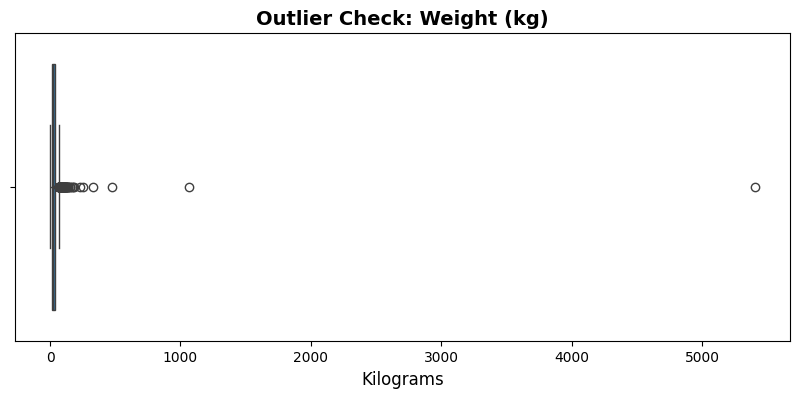

In [40]:
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.boxplot(x=final_df['Weight_kg'])
plt.title('Outlier Check: Weight (kg)', fontsize=14, fontweight='bold')
plt.xlabel('Kilograms', fontsize=12)
plt.show()

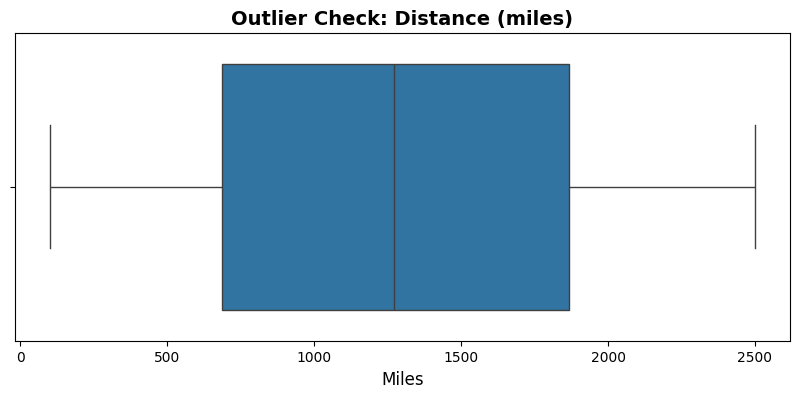

In [41]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=final_df['Distance_miles'])
plt.title('Outlier Check: Distance (miles)', fontsize=14, fontweight='bold')
plt.xlabel('Miles', fontsize=12)
plt.show()

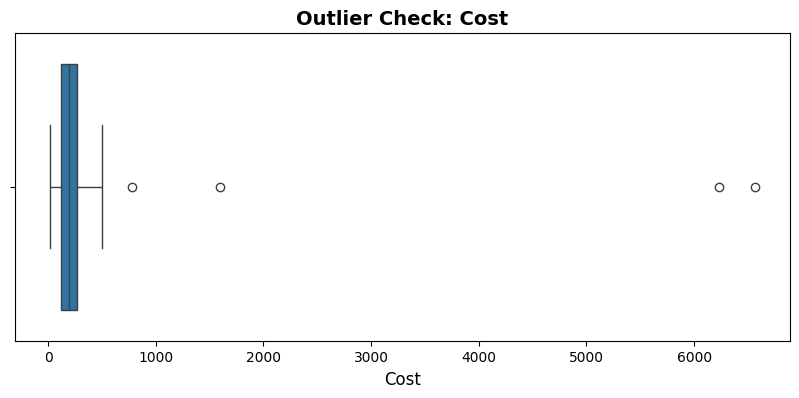

In [42]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=final_df['Cost'])
plt.title('Outlier Check: Cost', fontsize=14, fontweight='bold')
plt.xlabel('Cost', fontsize=12)
plt.show()

In [43]:
skew_score = final_df['Cost'].skew()
skew_score

np.float64(22.161835958859687)

<Axes: xlabel='Cost', ylabel='Count'>

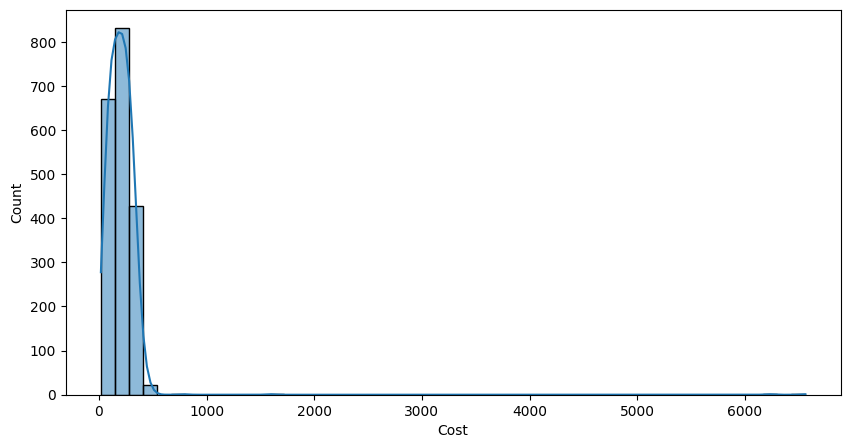

In [44]:
plt.figure(figsize=(10, 5))
sns.histplot(final_df['Cost'], bins=50, kde=True)

In [45]:
final_df['Log_Cost'] = np.log1p(final_df['Cost'])

In [46]:
new_skew_score = final_df['Log_Cost'].skew()
new_skew_score

np.float64(-0.5807043380479184)

<Axes: xlabel='Log_Cost', ylabel='Count'>

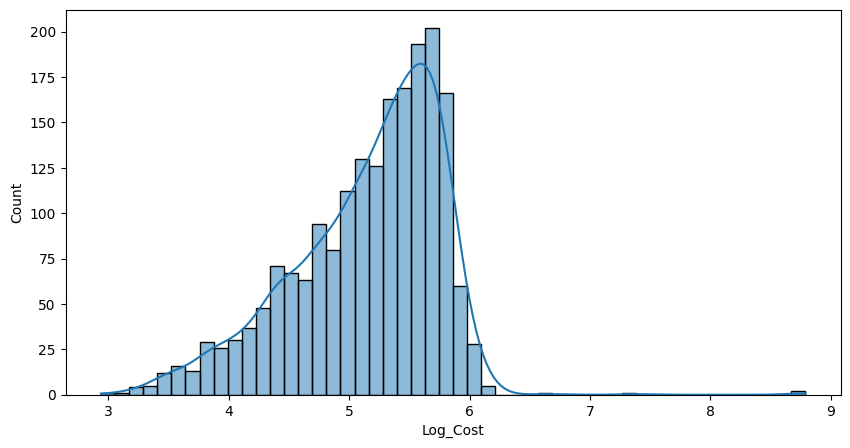

In [47]:
plt.figure(figsize=(10, 5))
sns.histplot(final_df['Log_Cost'], bins=50, kde=True)

In [49]:
import category_encoders as ce
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [50]:
X = final_df.drop(columns=['Cost', 'Log_Cost'])
y = final_df['Log_Cost']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
target_encoder = ce.TargetEncoder(cols=['Origin_Warehouse', 'Destination', 'Carrier'])
X_train_encoded = target_encoder.fit_transform(X_train, y_train)
X_test_encoded = target_encoder.transform(X_test)

In [53]:
final_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
final_model.fit(X_train_encoded, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [54]:
log_predictions = final_model.predict(X_test_encoded)

dollar_predictions = np.expm1(log_predictions)
dollar_actuals = np.expm1(y_test)

final_mae = mean_absolute_error(dollar_actuals, dollar_predictions)
final_mape = mean_absolute_percentage_error(dollar_actuals, dollar_predictions)

In [55]:
final_mae

18.909895781104822

In [56]:
final_mape

0.07707683897307532

### using ensemble learning

In [58]:
from sklearn.ensemble import VotingRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_percentage_error,mean_absolute_error

xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
lgb_model = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.04, num_leaves=31, random_state=42, verbose=-1)
cat_model = CatBoostRegressor(iterations=500, learning_rate=0.06, depth=6, random_seed=42, verbose=False)

ensemble_model = VotingRegressor(
    estimators=[
        ('xgb', xgb_model),
        ('lgb', lgb_model),
        ('cat', cat_model)
    ],
    weights=[1, 1, 2]
)

In [59]:
ensemble_model.fit(X_train_encoded, y_train)

VotingRegressor(estimators=[('xgb',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constrain...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=500,
                                          n_jobs=None, num_parallel_tree=None, ...)),
                            ('lgb',
                             LGBMRegressor(learning_rate=0.04, n_estimators=600,
                                           random_state=42, verbose=-1)),
                            ('cat',
                             CatBoostRegressor(depth=6, iterations=500, learning_rate=0.06, loss_function='RMSE', random_seed=42, verbose=False))],
                weights=[1, 1, 2])

In [60]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import numpy as np

train_log_preds = ensemble_model.predict(X_train_encoded)
train_dollar_preds = np.expm1(train_log_preds)
train_dollar_actuals = np.expm1(y_train)

train_mae = mean_absolute_error(train_dollar_actuals, train_dollar_preds)
train_mape = mean_absolute_percentage_error(train_dollar_actuals, train_dollar_preds)

print(f"TRAIN MAPE: {train_mape * 100:.2f}%  |  TEST MAPE: 6.78%")
print(f"TRAIN MAE:  ${train_mae:.2f}     |  TEST MAE:  $16.86")

TRAIN MAPE: 3.26%  |  TEST MAPE: 6.78%
TRAIN MAE:  $9.91     |  TEST MAE:  $16.86


In [61]:
import joblib

joblib.dump(ensemble_model, 'freight_ensemble_model.pkl')

['freight_ensemble_model.pkl']